In [1]:
import sys
print(sys.executable)


C:\Users\User1\anaconda3\python.exe


In [2]:
!{sys.executable} -m pip install sqlalchemy


In [3]:
import pandas as pd

# Load movies dataset
movies = pd.read_csv('movies.csv')

# Extract year from title
# This looks for a 4-digit number inside parentheses at the end of the title
movies['Year'] = movies['title'].str.extract(r'\((\d{4})\)')

# Optional: convert Year to integer
movies['Year'] = movies['Year'].astype(float)  # use float if some years are missing

# Check result
print(movies[['title', 'Year']].head(10))

                                title    Year
0                    Toy Story (1995)  1995.0
1                      Jumanji (1995)  1995.0
2             Grumpier Old Men (1995)  1995.0
3            Waiting to Exhale (1995)  1995.0
4  Father of the Bride Part II (1995)  1995.0
5                         Heat (1995)  1995.0
6                      Sabrina (1995)  1995.0
7                 Tom and Huck (1995)  1995.0
8                 Sudden Death (1995)  1995.0
9                    GoldenEye (1995)  1995.0


In [4]:
import pandas as pd

# Load data
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

# -----------------------------
# 1. Extract Year from title
# -----------------------------
movies['Year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['Year'] = movies['Year'].astype(float)  # float in case some years are missing

# -----------------------------
# 2. Add Average Rating & Total Ratings
# -----------------------------
# Compute avg rating and total ratings per movie
movie_stats = ratings.groupby('movieId')['rating'].agg(['mean','count']).reset_index()
movie_stats.rename(columns={'mean':'AvgRating', 'count':'TotalRatings'}, inplace=True)

# Merge stats with movies
movies = movies.merge(movie_stats, left_on='movieId', right_on='movieId', how='left')

# Fill NaN for movies with no ratings
movies['AvgRating'] = movies['AvgRating'].fillna(0)
movies['TotalRatings'] = movies['TotalRatings'].fillna(0)

# -----------------------------
# 3. Check results
# -----------------------------
print(movies[['movieId', 'title', 'Year', 'AvgRating', 'TotalRatings']].head(10))


   movieId                               title    Year  AvgRating  \
0        1                    Toy Story (1995)  1995.0   3.920930   
1        2                      Jumanji (1995)  1995.0   3.431818   
2        3             Grumpier Old Men (1995)  1995.0   3.259615   
3        4            Waiting to Exhale (1995)  1995.0   2.357143   
4        5  Father of the Bride Part II (1995)  1995.0   3.071429   
5        6                         Heat (1995)  1995.0   3.946078   
6        7                      Sabrina (1995)  1995.0   3.185185   
7        8                 Tom and Huck (1995)  1995.0   2.875000   
8        9                 Sudden Death (1995)  1995.0   3.125000   
9       10                    GoldenEye (1995)  1995.0   3.496212   

   TotalRatings  
0         215.0  
1         110.0  
2          52.0  
3           7.0  
4          49.0  
5         102.0  
6          54.0  
7           8.0  
8          16.0  
9         132.0  


In [5]:
# Movie Dimension Table
DimMovie = movies[['movieId', 'title', 'genres', 'Year', 'AvgRating', 'TotalRatings']]
DimMovie.to_csv('DimMovie.csv', index=False)  # optional export
print("Movie Dimension Table created:")
print(DimMovie.head())

Movie Dimension Table created:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres    Year  AvgRating  \
0  Adventure|Animation|Children|Comedy|Fantasy  1995.0   3.920930   
1                   Adventure|Children|Fantasy  1995.0   3.431818   
2                               Comedy|Romance  1995.0   3.259615   
3                         Comedy|Drama|Romance  1995.0   2.357143   
4                                       Comedy  1995.0   3.071429   

   TotalRatings  
0         215.0  
1         110.0  
2          52.0  
3           7.0  
4          49.0  


In [6]:
from sklearn.cluster import KMeans

# Compute user-level stats
DimUser = ratings.groupby('userId').agg(
    AvgRating=('rating', 'mean'),
    TotalRatings=('rating', 'count')
).reset_index()

# Create user-movie matrix for clustering
user_movie_matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
DimUser['Cluster'] = kmeans.fit_predict(user_movie_matrix)

# Save user dimension table
DimUser.to_csv('DimUser.csv', index=False)
print("User Dimension Table created:")
print(DimUser.head())


User Dimension Table created:
   userId  AvgRating  TotalRatings  Cluster
0       1   4.366379           232        2
1       2   3.948276            29        3
2       3   2.435897            39        3
3       4   3.555556           216        3
4       5   3.636364            44        0


In [7]:
FactRatings = ratings[['userId', 'movieId', 'rating', 'timestamp']]
FactRatings.to_csv('FactRatings.csv', index=False)
print("Fact Table created:")
print(FactRatings.head())

Fact Table created:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [8]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///movie_warehouse.db')

DimMovie.to_sql('DimMovie', con=engine, if_exists='replace', index=False)
DimUser.to_sql('DimUser', con=engine, if_exists='replace', index=False)
FactRatings.to_sql('FactRatings', con=engine, if_exists='replace', index=False)

print("SQLite Data Warehouse created with all tables!")

SQLite Data Warehouse created with all tables!


In [9]:
import sqlite3

# Create a SQLite database in the current folder
conn = sqlite3.connect('movie_warehouse.db')
cursor = conn.cursor()

# Create tables
movies.to_sql('movies', conn, if_exists='replace', index=False)
ratings.to_sql('ratings', conn, if_exists='replace', index=False)

print("Database and tables created successfully!")


Database and tables created successfully!


In [10]:
import pandas as pd



# Load movies and ratings from the current folder
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

# Display the first 5 rows to verify
print("Movies DataFrame:")
print(movies.head(), "\n")

print("Ratings DataFrame:")
print(ratings.head())

Movies DataFrame:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy   

Ratings DataFrame:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


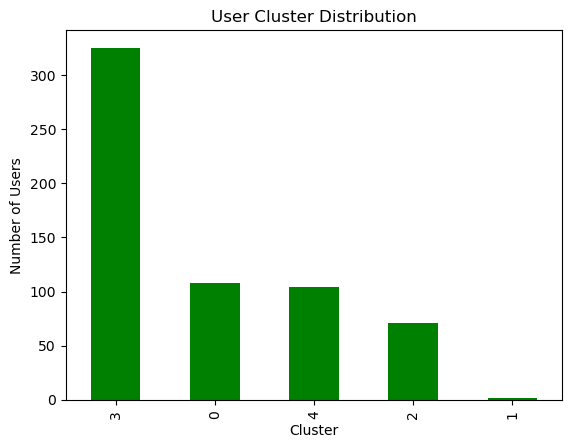

9742

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
from sqlalchemy import create_engine

# Load data
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

# ------------------------------
# 1. Enrich movie table
# ------------------------------
# Average rating and total ratings per movie
movies['AvgRating'] = ratings.groupby('movieId')['rating'].transform('mean')
movies['TotalRatings'] = ratings.groupby('movieId')['rating'].transform('count')

# ------------------------------
# 2. Create user dimension
# ------------------------------
users_dim = ratings.groupby('userId').agg(
    AvgRating=('rating', 'mean'),
    TotalRatings=('rating', 'count')
).reset_index()

# ------------------------------
# 3. User clustering
# ------------------------------
user_movie_matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)
kmeans = KMeans(n_clusters=5, random_state=42)
users_dim['Cluster'] = kmeans.fit_predict(user_movie_matrix)

# ------------------------------
# 4. Plot user cluster distribution
# ------------------------------
users_dim['Cluster'].value_counts().plot(kind='bar', color='green', title='User Cluster Distribution')
plt.xlabel("Cluster")
plt.ylabel("Number of Users")
plt.show()


engine = create_engine('sqlite:///movie_warehouse.db')
users_dim.to_sql('DimUser', con=engine, if_exists='replace', index=False)
movies.to_sql('DimMovie', con=engine, if_exists='replace', index=False)




In [12]:
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')
# Average rating for each movie
movie_popularity = ratings.groupby('movieId')['rating'].mean().reset_index()
# Merge with movie titles
movie_popularity = movie_popularity.merge(movies, on='movieId')
# Sort by rating descending
top_movies = movie_popularity.sort_values('rating', ascending=False)
print("Top 5 Popular Movies:")
print(top_movies[['title', 'rating']].head())

Top 5 Popular Movies:
                                      title  rating
7638  Paper Birds (Pájaros de papel) (2010)     5.0
8089             Act of Killing, The (2012)     5.0
9065                        Jump In! (2007)     5.0
9076                           Human (2015)     5.0
9078                    L.A. Slasher (2015)     5.0


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

# Create genre features
genre_dummies = movies['genres'].str.get_dummies(sep='|')
similarity_matrix = cosine_similarity(genre_dummies)
similarity_df = pd.DataFrame(similarity_matrix, index=movies['movieId'], columns=movies['movieId'])

def content_based_recommendation(user_id, top_n=5):
    user_rated = ratings[ratings['userId'] == user_id]
    if user_rated.empty:
        return movies.head(top_n)  # fallback to top movies
    
    top_movie_id = user_rated.sort_values('rating', ascending=False).iloc[0]['movieId']
    sim_scores = similarity_df[top_movie_id].sort_values(ascending=False)
    sim_scores = sim_scores.drop(user_rated['movieId'].values, errors='ignore')
    
    top_recommend_ids = sim_scores.head(top_n).index
    return movies[movies['movieId'].isin(top_recommend_ids)][['movieId', 'title']]

def precision_at_k(user_id, recommended_movies, k=5):
    user_movies = ratings[ratings['userId']==user_id].sort_values('rating', ascending=False)['movieId'].head(k)
    hits = recommended_movies['movieId'].isin(user_movies).sum()
    return hits / k

recommended = content_based_recommendation(1)
print("Precision@5:", precision_at_k(1, recommended))


Precision@5: 0.0


In [14]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer

# Convert genres into a matrix
count = CountVectorizer(tokenizer=lambda x: x.split('|'))
genre_matrix = count.fit_transform(movies['genres'])

# Compute similarity between movies
cosine_sim = cosine_similarity(genre_matrix, genre_matrix)

# Function to recommend similar movies based on a movie
def content_based_recommendation(movie_title, top_n=5):
    idx = movies[movies['title'] == movie_title].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices]

print("Content-Based Recommendations for 'Toy Story (1995)':")
print(content_based_recommendation('Toy Story (1995)'))



C:\Users\User1\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:523: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Content-Based Recommendations for 'Toy Story (1995)':
1706                                       Antz (1998)
2355                                Toy Story 2 (1999)
2809    Adventures of Rocky and Bullwinkle, The (2000)
3000                  Emperor's New Groove, The (2000)
3568                             Monsters, Inc. (2001)
Name: title, dtype: object


In [15]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Create user-item matrix
user_movie_matrix = ratings.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Compute similarity between users
user_similarity = cosine_similarity(user_movie_matrix)

# Recommend movies for a user
def collaborative_recommendation(user_id, top_n=5):
    user_idx = user_id - 1  # assuming userId starts at 1
    sim_scores = user_similarity[user_idx]
    user_ratings = user_movie_matrix.iloc[user_idx]
    unrated_movies = user_ratings[user_ratings == 0].index
    scores = {movie: sim_scores @ user_movie_matrix[movie] / sim_scores.sum() for movie in unrated_movies}
    recommended_movie_ids = sorted(scores, key=scores.get, reverse=True)[:top_n]
    return movies[movies['movieId'].isin(recommended_movie_ids)]['title'].tolist()

print("Collaborative Recommendations for UserID 18:")
print(collaborative_recommendation(188))


Collaborative Recommendations for UserID 18:
['Star Wars: Episode IV - A New Hope (1977)', 'Pulp Fiction (1994)', 'Shawshank Redemption, The (1994)', 'Silence of the Lambs, The (1991)', 'Matrix, The (1999)']


In [16]:
#save the CSV data in SQLite to show how a data warehouse works:
import sqlite3

conn = sqlite3.connect('movie_warehouse.db')
movies.to_sql('movies', conn, if_exists='replace', index=False)
ratings.to_sql('ratings', conn, if_exists='replace', index=False)

print("Database created successfully!")

Database created successfully!


In [18]:
# Example: content-based
movie_name = input("Enter a movie name: ")
print(content_based_recommendation(movie_name))

# Example: collaborative filtering
user_id = int(input("Enter user ID: "))
print(collaborative_recommendation(user_id))

def content_based_recommendation(movie_title, top_n=5):
    matches = movies[movies['title'].str.lower() == movie_title.lower()]
    if matches.empty:
        return f"Movie '{movie_title}' not found in dataset."
    
    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices]


Enter a movie name: Pulp Fiction (1994)
520                                          Fargo (1996)
791                                        Freeway (1996)
2453    Man Bites Dog (C'est arrivé près de chez vous)...
3155                           Beautiful Creatures (2000)
4169               Confessions of a Dangerous Mind (2002)
Name: title, dtype: object
Enter user ID: 1
['Shawshank Redemption, The (1994)', 'Terminator 2: Judgment Day (1991)', 'Godfather, The (1972)', 'Sixth Sense, The (1999)', 'Lord of the Rings: The Fellowship of the Ring, The (2001)']


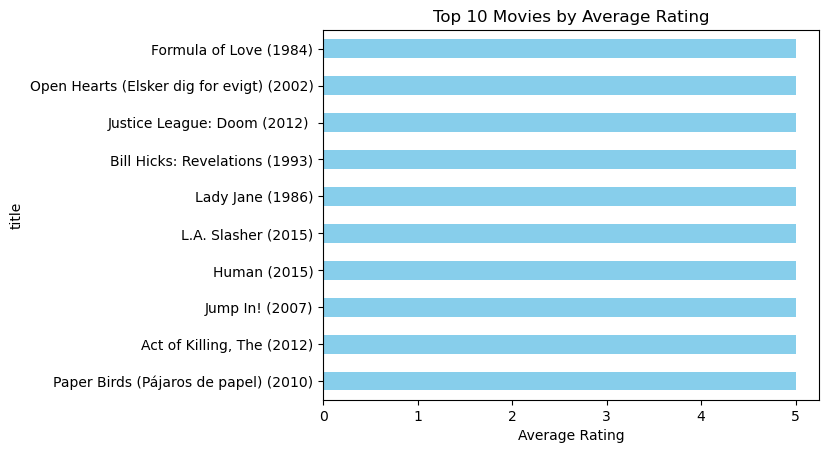

In [19]:
import matplotlib.pyplot as plt

top_movies[['title','rating']].head(10).plot(kind='barh', x='title', y='rating', color='skyblue', legend=False)
plt.title("Top 10 Movies by Average Rating")
plt.xlabel("Average Rating")
plt.show()

In [20]:
# Calculate average rating per movie
movie_popularity = ratings.groupby('movieId')['rating'].mean().reset_index()

# Merge with movies
movie_popularity = movie_popularity.merge(movies, on='movieId')

# Sort by rating descending
top_movies = movie_popularity.sort_values('rating', ascending=False)
print(top_movies[['title', 'rating']].head(10))

                                          title  rating
7638      Paper Birds (Pájaros de papel) (2010)     5.0
8089                 Act of Killing, The (2012)     5.0
9065                            Jump In! (2007)     5.0
9076                               Human (2015)     5.0
9078                        L.A. Slasher (2015)     5.0
4245                           Lady Jane (1986)     5.0
8136             Bill Hicks: Revelations (1993)     5.0
8130               Justice League: Doom (2012)      5.0
4240  Open Hearts (Elsker dig for evigt) (2002)     5.0
9104                     Formula of Love (1984)     5.0


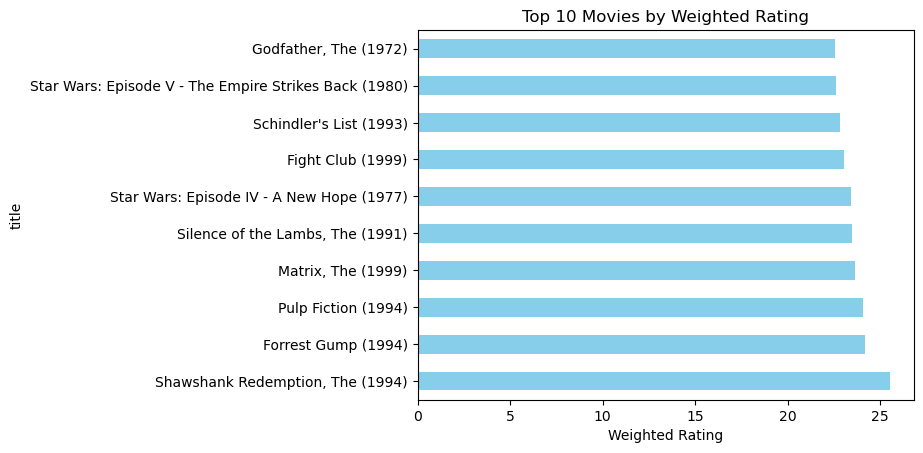

In [21]:
# Count number of ratings per movie
movie_counts = ratings.groupby('movieId')['rating'].count().reset_index()
movie_counts.rename(columns={'rating':'num_ratings'}, inplace=True)

# Merge with top_movies
top_movies = top_movies.merge(movie_counts, on='movieId')

# Weighted score: average rating * log(num_ratings+1)
import numpy as np
top_movies['weighted_rating'] = top_movies['rating'] * np.log(top_movies['num_ratings'] + 1)

# Sort by weighted_rating
top_movies_sorted = top_movies.sort_values('weighted_rating', ascending=False)

# Plot top 10 movies by weighted rating
top_movies_sorted[['title', 'weighted_rating']].head(10).plot(
    kind='barh', x='title', y='weighted_rating', color='skyblue', legend=False
)
plt.title("Top 10 Movies by Weighted Rating")
plt.xlabel("Weighted Rating")
plt.show()


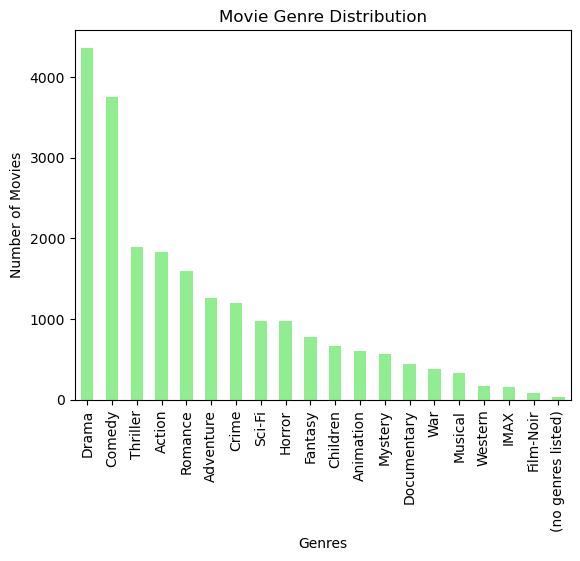

In [22]:
# 3. Genre Distribution
# -----------------------------
# Split genres by '|'
all_genres = movies['genres'].str.split('|').explode()

# Count frequency
genre_counts = all_genres.value_counts()

# Plot
genre_counts.plot(kind='bar', color='lightgreen')
plt.title("Movie Genre Distribution")
plt.xlabel("Genres")
plt.ylabel("Number of Movies")
plt.show()

In [23]:
query = "SELECT title, COUNT(*) as rating_count, AVG(rating) as avg_rating FROM ratings r JOIN movies m ON r.movieId = m.movieId GROUP BY r.movieId ORDER BY avg_rating DESC LIMIT 10"
top_query_movies = pd.read_sql(query, conn)
print(top_query_movies)

                                              title  rating_count  avg_rating
0                  Won't You Be My Neighbor? (2018)             1         5.0
1                           De platte jungle (1978)             1         5.0
2                             Blue Planet II (2017)             1         5.0
3                             Loving Vincent (2017)             1         5.0
4                                      Black Mirror             1         5.0
5                      Bobik Visiting Barbos (1977)             1         5.0
6        In the blue sea, in the white foam. (1984)             1         5.0
7  On the Trail of the Bremen Town Musicians (1973)             1         5.0
8                         Gena the Crocodile (1969)             1         5.0
9                                  Obsession (1965)             1         5.0
